# Corpus Data Preparation

Cleans and normalises the raw corpus, builds sentence embeddings, **automatically** finds
the best number of topic clusters, generates descriptive cluster names from the top words,
and writes `corpus_nodes_clustered.toml`.

**Workflow:**
1. Load all JSON files
2. Filter bad scrapes (`MIN_BODY_LEN`)
3. Clean / normalise text (encoding artefacts, boilerplate)
4. Embed with `sentence-transformers` — **full body, no truncation**
5. UMAP 2-D visualisation coloured by original prefix
6. Auto-select best k via silhouette score over `K_RANGE`
7. Apply KMeans; show UMAP coloured by cluster
8. **Auto-generate cluster names** from top TF-IDF terms
9. Inspect clusters; optionally override names in `CLUSTER_TO_NODE`
10. Export `corpus_nodes_clustered.toml`


## 0 — Configuration

All tunable parameters live here. Re-run the notebook after changing any value.


In [13]:
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
CORPUS_DIR      = Path("corpus")
EMBED_CACHE     = Path(".embeddings_cache.npy")  # delete to force re-encoding
OUTPUT_TOML     = Path("corpus_nodes_clustered.toml")
OUTPUT_MANIFEST = Path("cluster_assignments.json")

# ── Quality filter ─────────────────────────────────────────────────────────
MIN_BODY_LEN = 200  # characters after cleaning; shorter = likely bad scrape

# ── Embedding ──────────────────────────────────────────────────────────────
# Full body is encoded — no length cap.
# Swap model for quality vs. speed trade-off:
#   fast : all-MiniLM-L6-v2
#   best : all-mpnet-base-v2
EMBED_MODEL = "all-mpnet-base-v2"

# ── UMAP ───────────────────────────────────────────────────────────────────
UMAP_NEIGHBORS = 15
UMAP_MIN_DIST  = 0.1
RANDOM_STATE   = 42

# ── Dynamic clustering ─────────────────────────────────────────────────────
# The notebook scans every k in K_RANGE and picks the one with the highest
# silhouette score automatically.
# Set FORCE_K to an int to skip the search and use that k directly.
K_RANGE = (4, 20)   # (min_k, max_k) inclusive
FORCE_K = None      # e.g. FORCE_K = 8 to lock a specific k

# ── Cluster naming ──────────────────────────────────────────────────────────
# Auto-generated names from top TF-IDF terms. Leave empty dict to use auto-names.
# Override specific clusters by filling in cluster_id -> custom_name.
CLUSTER_TO_NODE: dict[int, str] = {
    # 0: "my_custom_name",   # override auto-generated name
    # 1: "another_name",
}

print("Config OK")


Config OK


## 1 — Load corpus


In [3]:
import json
import pandas as pd

records = []
for path in sorted(CORPUS_DIR.glob("*.json")):
    try:
        doc = json.loads(path.read_text(encoding="utf-8"))
    except Exception as e:
        records.append({"file": path.name, "url": "", "title": "",
                        "body": "", "topic_prefix": "PARSE_ERROR",
                        "parse_error": str(e)})
        continue
    name         = path.name
    topic_prefix = name.split("__")[0] if "__" in name else "(no prefix)"
    records.append({
        "file":         name,
        "url":          doc.get("url", ""),
        "title":        doc.get("title", ""),
        "body":         doc.get("body", ""),
        "topic_prefix": topic_prefix,
        "parse_error":  "",
    })

df = pd.DataFrame(records)
print(f"Total files: {len(df)}")
print()
print("Files per topic prefix:")
print(df["topic_prefix"].value_counts().to_string())


Total files: 984

Files per topic prefix:
topic_prefix
programming              126
ml_algorithms            109
smart_manufacturing       91
medicine                  81
space                     72
sustainable_materials     69
quantum_computing         66
neuroscience              64
economics                 63
climate_change            56
football                  51
docs_python_org           29
doi_org                   27
www_nasa_gov              23
arxiv_org                 20
en_wikipedia_org          18
climate_nasa_gov          14
openalex_org               3
stackoverflow_com          2


## 2 — Clean & normalise text

Fixes encoding artefacts (mojibake), strips residual HTML, and removes JS boilerplate
left by the scraper. Inspect the before/after examples to verify correctness.


In [4]:
import re
import html

# Mojibake: UTF-8 characters that were decoded as Latin-1 during scraping.
# We map the garbled byte sequences back to the correct Unicode characters.
_MOJIBAKE = {
    "\u00c2\u00b6": "\u00b6",          # paragraph sign
    "\u00e2\u20ac\u2122": "'",         # right single quotation
    "\u00e2\u20ac\u0153": '"',         # left double quotation
    "\u00e2\u20ac\u009d": '"',         # right double quotation
    "\u00e2\u20ac\u201c": "\u2013",    # en dash
    "\u00e2\u20ac\u201d": "\u2014",    # em dash
    "\u00e2\u20ac\u00a6": "\u2026",    # ellipsis
    "\u00c2\u00a9": "\u00a9",          # copyright
    "\u00c2\u00ae": "\u00ae",          # registered trademark
    "\u00c2\u00b7": "\u00b7",          # middle dot
    "\u00c2\u00a0": " ",               # non-breaking space
}

# Boilerplate phrases that indicate a failed or partial scrape.
_BOILERPLATE = re.compile(
    r"Loading component\.{0,3}"
    r"|Past Events\s+View Upcoming"
    r"|This content is now at"
    r"|Please enable JavaScript"
    r"|To view this (video|page) please enable"
    r"|Cookie\s+(Policy|Settings|Notice)"
    , re.IGNORECASE,
)

def clean_text(text: str) -> str:
    if not text:
        return ""
    text = html.unescape(text)                       # &amp; &lt; etc.
    for bad, good in _MOJIBAKE.items():              # fix mojibake
        text = text.replace(bad, good)
    text = re.sub(r"<[^>]{1,200}>", " ", text)      # strip HTML tags
    text = _BOILERPLATE.sub(" ", text)              # remove boilerplate
    text = re.sub(r"[ \t]{2,}", " ", text)          # collapse spaces
    text = re.sub(r"\n{3,}", "\n\n", text)          # collapse blank lines
    return text.strip()


df["title_clean"] = df["title"].apply(clean_text)
df["body_clean"]  = df["body"].apply(clean_text)
df["body_len"]    = df["body_clean"].str.len()

# Spot-check: show a few files where cleaning changed something.
SPOT_CHECK_N = 3
changed = df[df["body_clean"] != df["body"]].head(SPOT_CHECK_N)
for _, row in changed.iterrows():
    print(f"FILE: {row['file']}")
    print(f"  BEFORE: {row['body'][:200]!r}")
    print(f"  AFTER : {row['body_clean'][:200]!r}")
    print()
print(f"Total docs with cleaning changes: {len(df[df['body_clean'] != df['body']])}")


FILE: arxiv_org__abs_2012_10386v1.json
  BEFORE: 'Assessments of impacts of climate change and future projections over the Indian region, have so far relied on a single regional climate model (RCM) - eg., the PRECIS RCM of the Hadley Centre, UK. Whil'
  AFTER : 'Assessments of impacts of climate change and future projections over the Indian region, have so far relied on a single regional climate model (RCM) - eg., the PRECIS RCM of the Hadley Centre, UK. Whil'

FILE: arxiv_org__abs_2306_04338v1.json
  BEFORE: 'Data science has become increasingly essential for the production of official statistics, as it enables the automated collection, processing, and analysis of large amounts of data. With such data scie'
  AFTER : 'Data science has become increasingly essential for the production of official statistics, as it enables the automated collection, processing, and analysis of large amounts of data. With such data scie'

FILE: climate_change__arxiv_org__abs_2012_10386v1.json
  BEFORE: 'As

## 3 — Filter bad documents


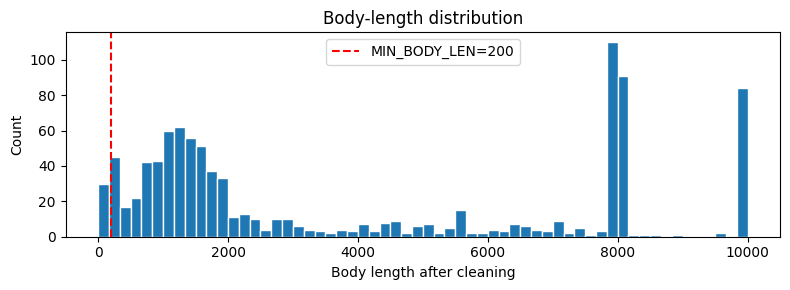


Documents below MIN_BODY_LEN (200 chars): 41


,file,body_len,body_clean
33,climate_change__doi_org__10_1016_j_dsr2_2020_1...,182,Oceanography Environmental science Continental...
64,climate_change__www_imf_org__en_publications_c...,0,
65,climate_change__www_imf_org__en_publications_p...,0,
66,climate_change__www_imf_org__en_publications_p...,0,
67,climate_change__www_imf_org__en_publications_p...,44,IMF Publications by Author Browse by Subject
68,climate_change__www_imf_org__en_publications_s...,0,
69,climate_change__www_imf_org__en_publications_w...,0,
73,climate_change__www_unep_org__events.json,0,
121,doi_org__10_1007_s10971_006_7762_7.json,187,Aerogel Mars Exploration Program Hypervelocity...
162,economics__doi_org__10_1016_0749_5978_85_90049...,129,Sunk costs Investment (military) Economics Mic...


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(df["body_len"].clip(upper=10000), bins=60, edgecolor="white")
ax.axvline(MIN_BODY_LEN, color="red", linestyle="--",
           label=f"MIN_BODY_LEN={MIN_BODY_LEN}")
ax.set_xlabel("Body length after cleaning")
ax.set_ylabel("Count")
ax.set_title("Body-length distribution")
ax.legend()
plt.tight_layout(); plt.show()

bad = df[df["body_len"] < MIN_BODY_LEN]
print(f"\nDocuments below MIN_BODY_LEN ({MIN_BODY_LEN} chars): {len(bad)}")
bad[["file", "body_len", "body_clean"]]


In [7]:
# Add filenames here to force-keep a document despite being below MIN_BODY_LEN.
FORCE_KEEP: set[str] = set()

clean = df[
    (df["body_len"] >= MIN_BODY_LEN) | df["file"].isin(FORCE_KEEP)
].copy()
clean = clean[clean["parse_error"] == ""].reset_index(drop=True)
excluded = df[~df["file"].isin(clean["file"])]

print(f"Excluded (bad scrapes) : {len(excluded)}")
print(f"Clean documents        : {len(clean)}")


Excluded (bad scrapes) : 41
Clean documents        : 943


## 4 — Embed documents (full text, no truncation)

Each document is encoded as `title + " " + full_body`.  
Embeddings are cached — delete `.embeddings_cache.npy` to force a fresh run.


In [8]:
import numpy as np

texts = (clean["title_clean"] + " " + clean["body_clean"]).tolist()

reload = True
if EMBED_CACHE.exists():
    embeddings = np.load(EMBED_CACHE)
    if embeddings.shape[0] == len(texts):
        print(f"Loaded cached embeddings: {embeddings.shape}")
        reload = False
    else:
        print(f"Cache has {embeddings.shape[0]} rows but corpus has {len(texts)} — re-encoding.")

if reload:
    from sentence_transformers import SentenceTransformer
    print(f"Encoding {len(texts)} documents with '{EMBED_MODEL}' (full text) ...")
    model = SentenceTransformer(EMBED_MODEL)
    embeddings = model.encode(texts, show_progress_bar=True, batch_size=16)
    np.save(EMBED_CACHE, embeddings)
    print(f"Saved -> {EMBED_CACHE}  shape={embeddings.shape}")


Loaded cached embeddings: (943, 768)


## 5 — UMAP: visualise by original topic prefix

Shows how well (or poorly) the original filename prefixes separate in embedding space.  
Overlapping colours = documents that likely don't belong to that prefix.


/home/lukas/Documents/Uni/THN/IntroBC/ColonySearch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/lukas/Documents/Uni/THN/IntroBC/ColonySearch/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_1433087/4281717009.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap      = plt.cm.get_cmap("tab20", len(prefixes))


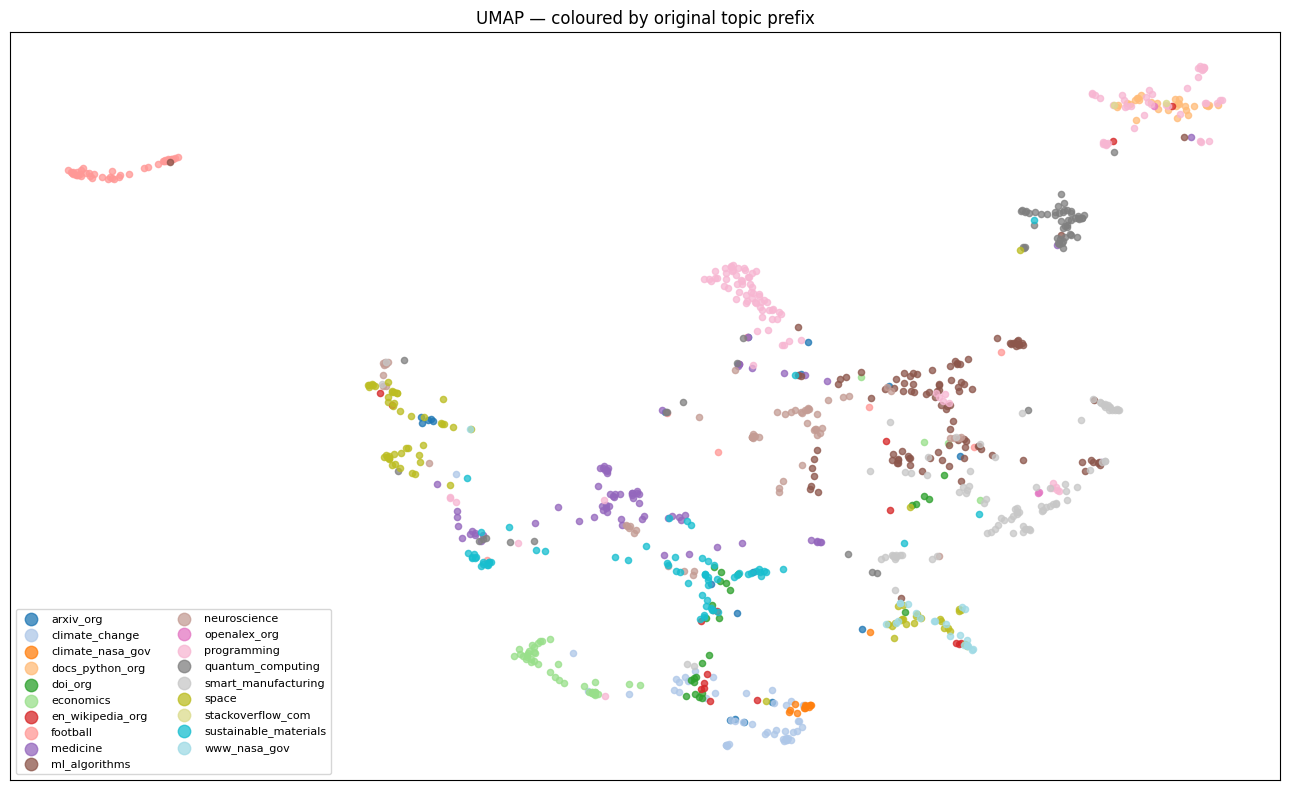

In [9]:
import umap as umap_lib

reducer = umap_lib.UMAP(
    n_neighbors  = UMAP_NEIGHBORS,
    min_dist     = UMAP_MIN_DIST,
    random_state = RANDOM_STATE,
    verbose      = False,
)
xy = reducer.fit_transform(embeddings)
clean["umap_x"] = xy[:, 0]
clean["umap_y"] = xy[:, 1]

prefixes  = sorted(clean["topic_prefix"].unique())
cmap      = plt.cm.get_cmap("tab20", len(prefixes))
color_map = {p: cmap(i) for i, p in enumerate(prefixes)}

fig, ax = plt.subplots(figsize=(13, 8))
for prefix, grp in clean.groupby("topic_prefix"):
    ax.scatter(grp["umap_x"], grp["umap_y"],
               c=[color_map[prefix]], label=prefix, s=20, alpha=0.75)
ax.legend(markerscale=2, fontsize=8, loc="best", ncol=2)
ax.set_title("UMAP — coloured by original topic prefix")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## 6 — Auto-select number of clusters

Scans every k in `K_RANGE` and picks the highest silhouette score automatically.  
Override with `FORCE_K` in the config cell once you know a good value.


Scanning k=4..20................. done


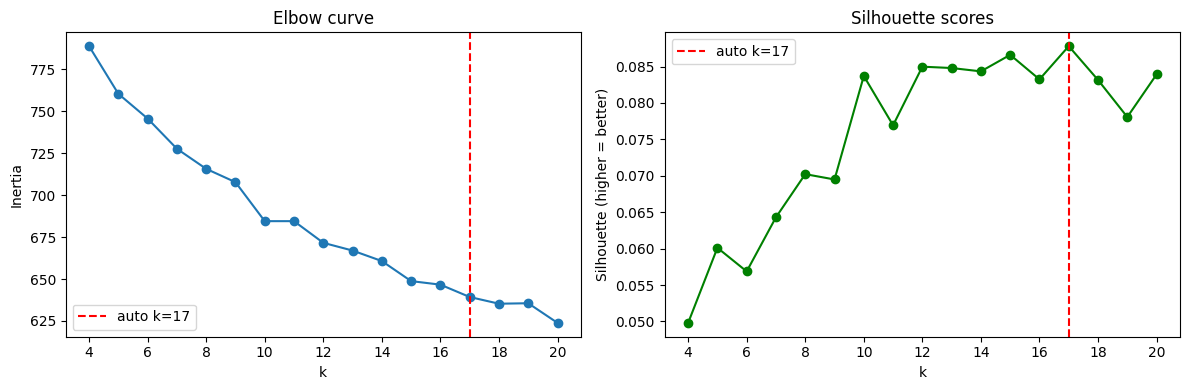


Auto-selected k=17  (silhouette=0.088)
To lock this: set FORCE_K=17 in the config cell.


In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

if FORCE_K is not None:
    best_k = FORCE_K
    print(f"FORCE_K={FORCE_K} — skipping auto-selection.")
else:
    k_min, k_max = K_RANGE
    k_range      = range(k_min, min(k_max + 1, len(clean) // 5))
    inertias, silhouettes = [], []

    print(f"Scanning k={k_min}..{k_max}", end="", flush=True)
    for k in k_range:
        km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        labels = km.fit_predict(embeddings)
        inertias.append(km.inertia_)
        sil    = silhouette_score(embeddings, labels,
                                  sample_size=min(600, len(clean)),
                                  random_state=RANDOM_STATE)
        silhouettes.append(sil)
        print(".", end="", flush=True)
    print(" done")

    best_idx = silhouettes.index(max(silhouettes))
    best_k   = list(k_range)[best_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(list(k_range), inertias, marker="o")
    ax1.axvline(best_k, color="red", linestyle="--", label=f"auto k={best_k}")
    ax1.set_xlabel("k"); ax1.set_ylabel("Inertia")
    ax1.set_title("Elbow curve"); ax1.legend()

    ax2.plot(list(k_range), silhouettes, marker="o", color="green")
    ax2.axvline(best_k, color="red", linestyle="--", label=f"auto k={best_k}")
    ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette (higher = better)")
    ax2.set_title("Silhouette scores"); ax2.legend()
    plt.tight_layout(); plt.show()

    print(f"\nAuto-selected k={best_k}  (silhouette={max(silhouettes):.3f})")
    print(f"To lock this: set FORCE_K={best_k} in the config cell.")


## 7 — Apply KMeans with auto-selected k


In [42]:
km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init="auto")
clean["cluster"] = km.fit_predict(embeddings)

print(f"Cluster sizes (k={best_k}):")
print(clean["cluster"].value_counts().sort_index().to_string())


Cluster sizes (k=18):
cluster
0      76
1      52
2      56
3      68
4      41
5      37
6      30
7      64
8      42
9      22
10     50
11     43
12     65
13     51
14     52
15     25
16     64
17    105


## 8 — Auto-generate cluster names from top words

Uses TF-IDF to extract the top 3 most relevant terms per cluster.  
Combines them into a readable cluster name like `quantum_computing_error_correction`.  
Override in `CLUSTER_TO_NODE` if the auto-name doesn't feel right.


In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# ── Extract top terms per cluster ──────────────────────────────────────────
def get_cluster_name(cluster_docs: list[str], n_words: int = 3) -> str:
    """Generate a cluster name from the top TF-IDF terms."""
    if not cluster_docs or len(cluster_docs) < 2:
        return "tiny_cluster"

    # Simple TF-IDF on the cluster alone
    vectorizer = TfidfVectorizer(
        max_features=200,
        ngram_range=(1, 2),
        stop_words="english",
        min_df=1,
        max_df=0.9,
    )
    try:
        tfidf_matrix = vectorizer.fit_transform(cluster_docs)
        # Sum TF-IDF scores per term
        scores = tfidf_matrix.sum(axis=0).A1
        top_indices = scores.argsort()[-n_words:][::-1]
        terms = [vectorizer.get_feature_names_out()[i] for i in top_indices]
        # Clean up: remove spaces from bigrams, join with underscore
        terms = [re.sub(r'\s+', '_', t) for t in terms if t.strip()]
        return "_".join(terms[:n_words])
    except Exception as e:
        print(f"Warning: naming failed — {e}")
        return "cluster_unknown"


# ── Generate names for all clusters ────────────────────────────────────────
auto_names = {}
for cid in sorted(clean["cluster"].unique()):
    cluster_docs = clean[clean["cluster"] == cid]["body_clean"].tolist()
    auto_names[cid] = get_cluster_name(cluster_docs)

# ── Apply overrides from CLUSTER_TO_NODE ──────────────────────────────────
final_names = {cid: CLUSTER_TO_NODE.get(cid, name) for cid, name in auto_names.items()}

print("Auto-generated cluster names:")
for cid, name in sorted(final_names.items()):
    src = "(auto)" if auto_names[cid] == name else "(custom)"
    print(f"  Cluster {cid:2d} -> {name:30s}  {src}")


Auto-generated cluster names:
  Cluster  0 -> learning_computer_economics     (auto)
  Cluster  1 -> data_ax_import                  (auto)
  Cluster  2 -> nasa_read_artemis               (auto)
  Cluster  3 -> manufacturing_digital_engineering  (auto)
  Cluster  4 -> climate_change_nasa_global      (auto)
  Cluster  5 -> software_cloud_00               (auto)
  Cluster  6 -> diffusion_image_score           (auto)
  Cluster  7 -> nih_health_gene                 (auto)
  Cluster  8 -> 2026_climate_economics          (auto)
  Cluster  9 -> circular_waste_packaging        (auto)
  Cluster 10 -> computer_variational_displaystyle  (auto)
  Cluster 11 -> league_data_model               (auto)
  Cluster 12 -> documentation_modules_object    (auto)
  Cluster 13 -> engineering_cellulose_material  (auto)
  Cluster 14 -> war_army_edit                   (auto)
  Cluster 15 -> ice_model_sea                   (auto)
  Cluster 16 -> earth_data_exoplanet            (auto)
  Cluster 17 -> learning_data

## 9 — UMAP coloured by cluster with auto-generated names


/tmp/ipykernel_1034841/1316310920.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_c = plt.cm.get_cmap("tab20", best_k)


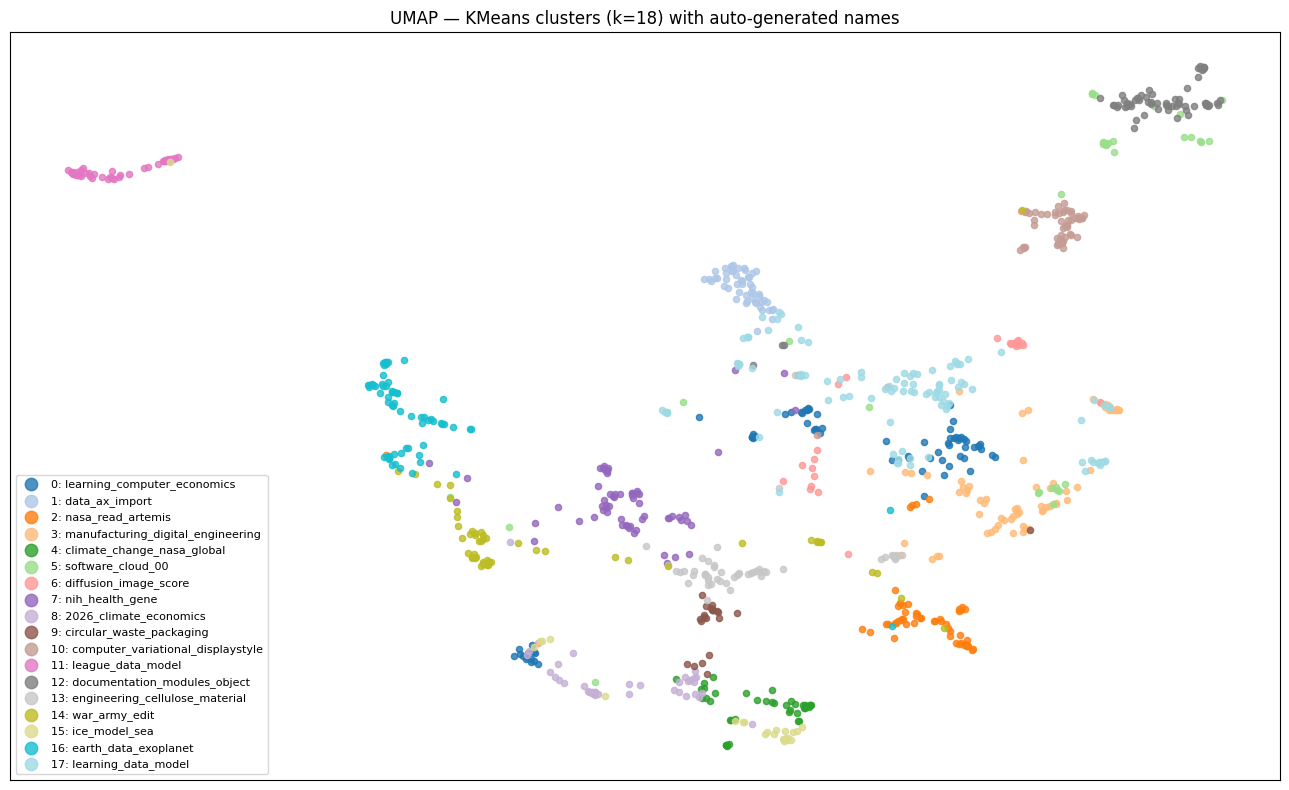

In [50]:
cmap_c = plt.cm.get_cmap("tab20", best_k)
fig, ax = plt.subplots(figsize=(13, 8))
for cid, grp in clean.groupby("cluster"):
    ax.scatter(grp["umap_x"], grp["umap_y"],
               c=[cmap_c(cid)], label=f"{cid}: {final_names[cid]}", s=20, alpha=0.8)
ax.legend(markerscale=2, fontsize=8, loc="best")
ax.set_title(f"UMAP — KMeans clusters (k={best_k}) with auto-generated names")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## 10 — Inspect clusters

Read the auto-generated names and sample docs. If you want to rename any cluster,  
go back to the **config cell** and add it to `CLUSTER_TO_NODE`, then re-run Cell 7 onward.


In [45]:
TOP_N = 8  # sample docs printed per cluster

for cid in sorted(clean["cluster"].unique()):
    grp        = clean[clean["cluster"] == cid]
    node_label = final_names[cid]
    dominant   = grp["topic_prefix"].value_counts().head(3).to_dict()
    print(f"{chr(9472)*70}")
    print(f"Cluster {cid:2d}  ->  {node_label:30s}  ({len(grp)} docs)")
    print(f"  Dominant prefix(es): {dominant}")
    for _, row in grp.head(TOP_N).iterrows():
        title = (row["title_clean"] or row["url"])[:90]
        print(f"  [{row['topic_prefix']}] {title}")
    print()


──────────────────────────────────────────────────────────────────────
Cluster  0  ->  learning_computer_economics     (76 docs)
  Dominant prefix(es): {'neuroscience': 29, 'ml_algorithms': 22, 'economics': 16}
  [arxiv_org] Climate Adaptation with Reinforcement Learning: Experiments with Flooding and Transportati
  [doi_org] Intelligent agents: theory and practice
  [doi_org] MAPGEN: mixed-initiative planning and scheduling for the Mars Exploration Rover mission
  [economics] Optimal strategies for a game on amenable semigroups
  [economics] Machine learning and behavioral economics for personalized choice architecture
  [economics] Reward Mechanism for Blockchains Using Evolutionary Game Theory
  [economics] Dynamic Structure in Four-strategy Game: Theory and Experiment
  [economics] Playing a 2D Game Indefinitely using NEAT and Reinforcement Learning

──────────────────────────────────────────────────────────────────────
Cluster  1  ->  data_ax_import                  (52 docs)
  Do

## 11 — Cross-tab: cluster vs original prefix


In [46]:
ct = pd.crosstab(clean["cluster"], clean["topic_prefix"])
ct.index = [f"{c} ({final_names[c]})" for c in ct.index]
print(ct.to_string())


topic_prefix                            arxiv_org  climate_change  climate_nasa_gov  docs_python_org  doi_org  economics  en_wikipedia_org  football  medicine  ml_algorithms  neuroscience  openalex_org  programming  quantum_computing  smart_manufacturing  space  stackoverflow_com  sustainable_materials  www_nasa_gov
0 (learning_computer_economics)                 1               0                 0                0        2         16                 1         1         0             22            29             0            0                  0                    4      0                  0                      0             0
1 (data_ax_import)                              0               0                 0                0        0          0                 0         0         0              0             0             0           52                  0                    0      0                  0                      0             0
2 (nasa_read_artemis)                         

## 12 — Export

Writes:
- **`cluster_assignments.json`** — `{filename: node_name}` for every clean document
- **`corpus_nodes_clustered.toml`** — drop-in replacement for `corpus_nodes.toml`

Then run: `python database_setup.py --config corpus_nodes_clustered.toml`


In [47]:
import json as _json
from collections import defaultdict

node_files: dict[str, list[str]] = defaultdict(list)
assignments: dict[str, str]      = {}

for _, row in clean.iterrows():
    cid       = int(row["cluster"])
    node_name = final_names[cid]
    node_files[node_name].append(row["file"])
    assignments[row["file"]] = node_name

OUTPUT_MANIFEST.write_text(
    _json.dumps(assignments, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Wrote {len(assignments)} entries -> {OUTPUT_MANIFEST}")

lines = [
    "# corpus_nodes_clustered.toml",
    f"# Auto-generated by data_preperation.ipynb  (k={best_k})",
    "# Cluster names auto-generated from TF-IDF top terms.",
    "# Do not edit by hand — re-run the notebook to regenerate.",
    "",
    "[corpus]",
    'dir = "corpus"',
    "",
    "[databases]",
    'dir = "dbs"',
    "",
]

all_files = sorted(clean["file"].tolist())
lines += ["[[node]]", 'name = "everything"']
lines.append("include = [")
for f in all_files:
    lines.append(f'  "{f}",')
lines += ["]", ""]

for node_name in sorted(node_files):
    files = sorted(node_files[node_name])
    lines += ["[[node]]", f'name = "{node_name}"']
    lines.append("include = [")
    for f in files:
        lines.append(f'  "{f}",')
    lines += ["]", ""]

OUTPUT_TOML.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {len(node_files)} nodes -> {OUTPUT_TOML}")
print()
print("Node summary (auto-generated names):")
for node, files in sorted(node_files.items()):
    print(f"  {node:35s}  {len(files):4d} docs")
print(f"  {'EXCLUDED (bad scrapes)':35s}  {len(excluded):4d} docs")


Wrote 943 entries -> cluster_assignments.json
Wrote 18 nodes -> corpus_nodes_clustered.toml

Node summary (auto-generated names):
  2026_climate_economics                 42 docs
  circular_waste_packaging               22 docs
  climate_change_nasa_global             41 docs
  computer_variational_displaystyle      50 docs
  data_ax_import                         52 docs
  diffusion_image_score                  30 docs
  documentation_modules_object           65 docs
  earth_data_exoplanet                   64 docs
  engineering_cellulose_material         51 docs
  ice_model_sea                          25 docs
  league_data_model                      43 docs
  learning_computer_economics            76 docs
  learning_data_model                   105 docs
  manufacturing_digital_engineering      68 docs
  nasa_read_artemis                      56 docs
  nih_health_gene                        64 docs
  software_cloud_00                      37 docs
  war_army_edit                      

## 13 — (Optional) Rebuild databases


In [48]:
# Uncomment to rebuild all node SQLite FTS5 databases immediately.
# import subprocess, sys
# result = subprocess.run(
#     [sys.executable, "database_setup.py", "--config", str(OUTPUT_TOML)],
#     capture_output=True, text=True,
# )
# print(result.stdout)
# if result.returncode != 0:
#     print("STDERR:", result.stderr)
